## EDA Notebook - Fern Data

### Load Data

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Set the root directory path by searching upward for pyproject.toml using pathlib
def find_root_with_pyproject(start: Path) -> Path:
    """Find the nearest ancestor directory containing pyproject.toml."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("pyproject.toml not found in any parent directories.")

ROOT = find_root_with_pyproject(Path.cwd())
RAW_DATA_DIR = ROOT / "data" / "raw"
PROCESSED_DATA_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"

# Print root directory
print(f"Root directory: {ROOT}")

# Print data directories
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Root directory: /Users/blytheberlinger/Documents/GitHub/fern-forecasting
Raw data directory: /Users/blytheberlinger/Documents/GitHub/fern-forecasting/data/raw
Processed data directory: /Users/blytheberlinger/Documents/GitHub/fern-forecasting/data/processed
Figures directory: /Users/blytheberlinger/Documents/GitHub/fern-forecasting/figures


In [3]:
# Data directory
calendar_df = pd.read_csv(RAW_DATA_DIR / "fern_calendar.csv")
inventory_df = pd.read_csv(RAW_DATA_DIR / "fern_inventory.csv")
orders_df = pd.read_csv(RAW_DATA_DIR / "fern_orders.csv")
reviews_df = pd.read_csv(RAW_DATA_DIR / "fern_reviews.csv")

### EDA

#### Calendar Data

In [4]:
calendar_df.head()

,date,holiday_name,days_until_next_major_holiday,is_university_event_week,is_weekend,season,avg_temp_f,precipitation_inches
0,2023-01-01,NaN,44,False,True,winter,32,0.63
1,2023-01-02,NaN,43,False,False,winter,29,0.00
2,2023-01-03,NaN,42,False,False,winter,33,0.00
3,2023-01-04,NaN,41,False,False,winter,38,0.00
4,2023-01-05,NaN,40,False,False,winter,29,0.11


In [5]:
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           731 non-null    object 
 1   holiday_name                   6 non-null      object 
 2   days_until_next_major_holiday  731 non-null    int64  
 3   is_university_event_week       731 non-null    bool   
 4   is_weekend                     731 non-null    bool   
 5   season                         731 non-null    object 
 6   avg_temp_f                     731 non-null    int64  
 7   precipitation_inches           731 non-null    float64
dtypes: bool(2), float64(1), int64(2), object(3)
memory usage: 35.8+ KB


In [6]:
print("Start Date: ", calendar_df["date"].min())
print("End Date: ", calendar_df["date"].max())


Start Date:  2023-01-01
End Date:  2024-12-31


In [7]:
# Holidays included
# List unique holidays, excluding NaNs
list(calendar_df["holiday_name"].dropna().unique())



["Valentine's Day", "Mother's Day", 'Christmas']

In [8]:
calendar_df.describe()

,days_until_next_major_holiday,avg_temp_f,precipitation_inches
count,731.00000,731.000000,731.000000
mean,382.28591,52.595075,0.077483
std,427.09262,16.836935,0.185267
min,0.00000,19.000000,0.000000
25%,45.50000,37.500000,0.000000
50%,143.00000,52.000000,0.000000
75%,999.00000,67.500000,0.035000
max,999.00000,95.000000,1.250000


In [9]:
calendar_df.isnull().sum()

date                               0
holiday_name                     725
days_until_next_major_holiday      0
is_university_event_week           0
is_weekend                         0
season                             0
avg_temp_f                         0
precipitation_inches               0
dtype: int64

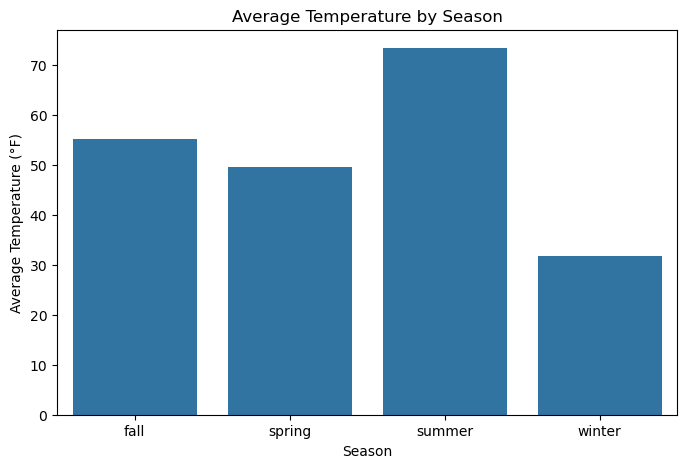

In [10]:
# Bar plot of average temperature by season
import matplotlib.pyplot as plt
import seaborn as sns

season_temp_means = calendar_df.groupby("season")["avg_temp_f"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=season_temp_means, x="season", y="avg_temp_f")
plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°F)")
plt.show()

Text(0.5, 0, 'Holiday Name')

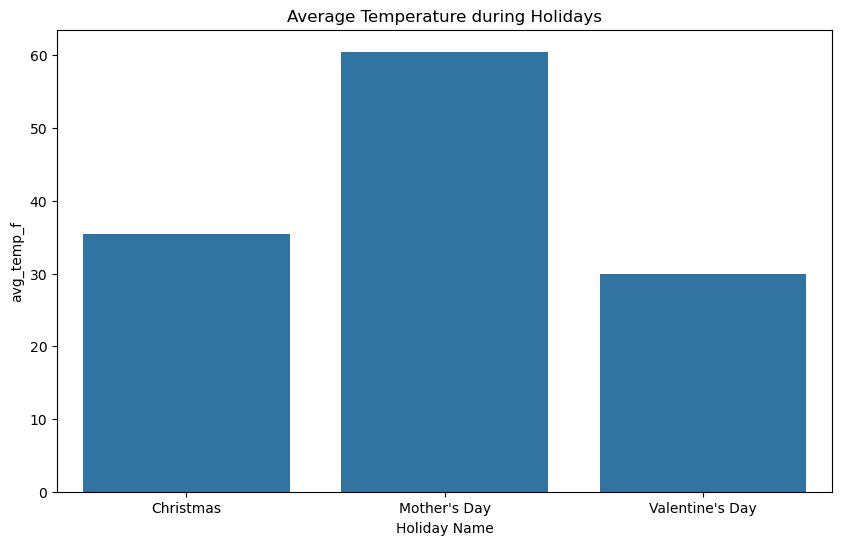

In [11]:
# Average temperature during holidays
holiday_temp_means = calendar_df[calendar_df["holiday_name"].notna()].groupby("holiday_name")["avg_temp_f"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_temp_means, x="holiday_name", y="avg_temp_f")
plt.title("Average Temperature during Holidays")
plt.xlabel("Holiday Name")



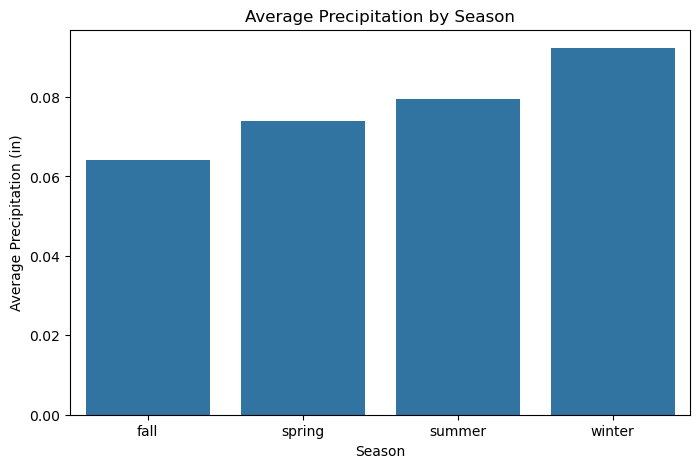

In [12]:
# Average precipitation by season
season_precip_means = calendar_df.groupby("season")["precipitation_inches"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=season_precip_means, x="season", y="precipitation_inches")
plt.title("Average Precipitation by Season")
plt.xlabel("Season")
plt.ylabel("Average Precipitation (in)")
plt.show()

Text(0, 0.5, 'Average Precipitation (in)')

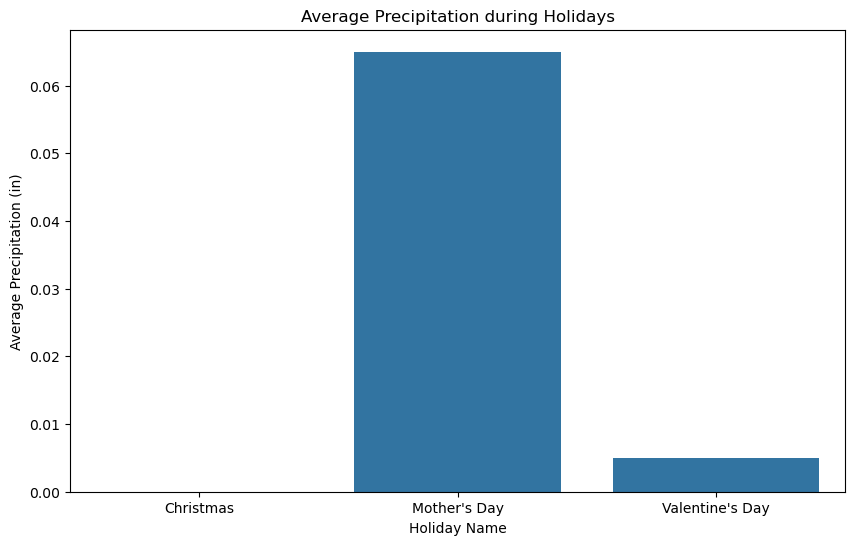

In [13]:
# Average precipitation during holidays
holiday_precip_means = calendar_df[calendar_df["holiday_name"].notna()].groupby("holiday_name")["precipitation_inches"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_precip_means, x="holiday_name", y="precipitation_inches")
plt.title("Average Precipitation during Holidays")
plt.xlabel("Holiday Name")
plt.ylabel("Average Precipitation (in)")

#### Inventory Data

In [14]:
inventory_df.head()

,order_week,product_category,units_ordered,units_sold,units_wasted,unit_cost,unit_price,restock_lead_time_days
0,2022-12-26,roses,5,5,0,5.11,13.46,3
1,2023-01-02,roses,5,5,0,4.72,12.41,3
2,2023-01-09,roses,20,18,2,4.58,12.06,3
3,2023-01-16,roses,17,17,0,4.72,12.41,3
4,2023-01-23,roses,21,16,5,5.27,13.87,3


In [15]:
inventory_df.tail()

,order_week,product_category,units_ordered,units_sold,units_wasted,unit_cost,unit_price,restock_lead_time_days
937,2024-12-02,ferns,23,23,0,4.16,11.88,3
938,2024-12-09,ferns,24,24,0,4.00,11.42,3
939,2024-12-16,ferns,30,30,0,4.15,11.85,3
940,2024-12-23,ferns,31,26,5,4.25,12.14,3
941,2024-12-30,ferns,33,12,21,3.77,10.77,3


In [16]:
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_week              942 non-null    object 
 1   product_category        942 non-null    object 
 2   units_ordered           942 non-null    int64  
 3   units_sold              942 non-null    int64  
 4   units_wasted            942 non-null    int64  
 5   unit_cost               942 non-null    float64
 6   unit_price              942 non-null    float64
 7   restock_lead_time_days  942 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 59.0+ KB


In [17]:
inventory_df.describe()

,units_ordered,units_sold,units_wasted,unit_cost,unit_price,restock_lead_time_days
count,942.000000,942.000000,942.000000,942.000000,942.000000,942.0
mean,25.264331,19.903397,5.360934,7.951019,20.091476,3.0
std,14.438229,12.472380,9.025368,4.259939,8.604614,0.0
min,2.000000,1.000000,0.000000,3.600000,10.500000,3.0
25%,16.000000,11.000000,0.000000,4.712500,13.292500,3.0
50%,22.000000,17.000000,0.000000,6.790000,17.880000,3.0
75%,31.000000,25.000000,8.000000,9.857500,23.472500,3.0
max,100.000000,76.000000,67.000000,18.450000,40.990000,3.0


In [18]:
inventory_df.isnull().sum()

order_week                0
product_category          0
units_ordered             0
units_sold                0
units_wasted              0
unit_cost                 0
unit_price                0
restock_lead_time_days    0
dtype: int64

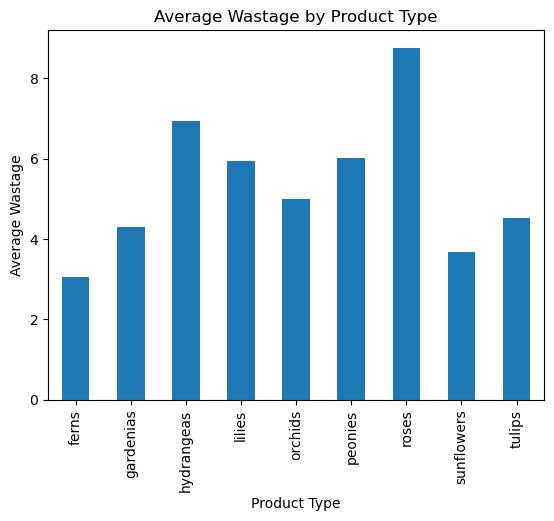

In [19]:
# Average wastage by product type
inventory_df.groupby("product_category")["units_wasted"].mean().plot(kind="bar")
plt.title("Average Wastage by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Wastage")
plt.show()


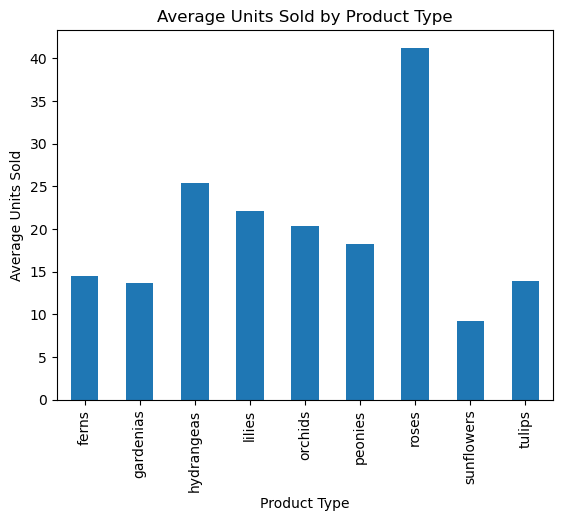

In [20]:
# Average units sold by product type
inventory_df.groupby("product_category")["units_sold"].mean().plot(kind="bar")
plt.title("Average Units Sold by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Units Sold")
plt.show()


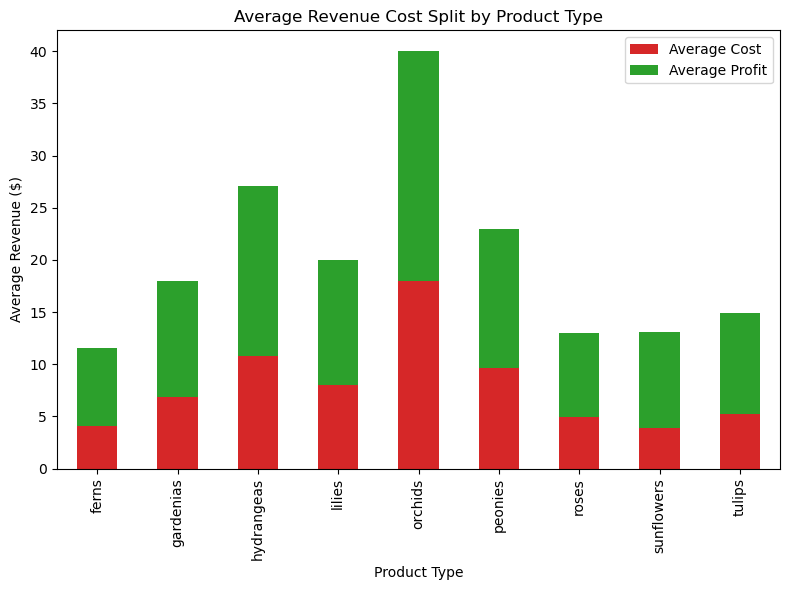

In [21]:
# Calculate average unit cost and average revenue by product_category
avg_unit_cost = inventory_df.groupby("product_category")["unit_cost"].mean()
avg_unit_price = inventory_df.groupby("product_category")["unit_price"].mean()

# Prepare dataframe for stacked bar chart: cost and profit component
cost_profit_df = (
    pd.DataFrame({
        "Average Cost": avg_unit_cost,
        "Average Profit": avg_unit_price - avg_unit_cost
    })
    .sort_index()
)

# Stacked bar plot
cost_profit_df.plot(
    kind="bar",
    stacked=True,
    color=["#d62728", "#2ca02c"],
    figsize=(8, 6)
)
plt.title("Average Revenue Cost Split by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Revenue ($)")
plt.legend(["Average Cost", "Average Profit"], loc="upper right")
plt.tight_layout()
plt.show()

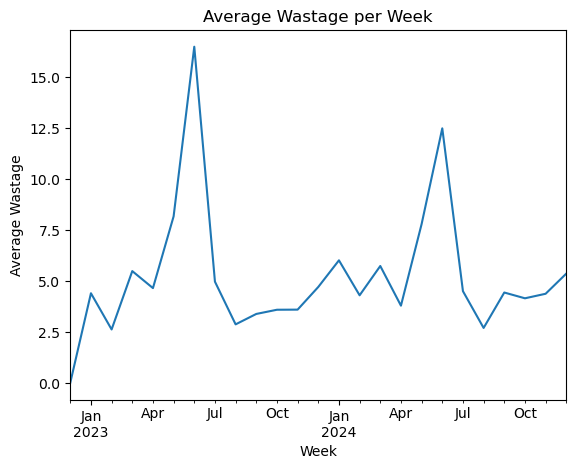

In [22]:
# Average wastage per month

# Ensure 'order_week' is in datetime format; convert if not
if not pd.api.types.is_datetime64_any_dtype(inventory_df["order_week"]):
    inventory_df["order_week"] = pd.to_datetime(inventory_df["order_week"])

# Group by week and calculate the mean of units_wasted
weekly_wastage = (
    inventory_df.groupby(inventory_df["order_week"].dt.to_period("M"))["units_wasted"]
    .mean()
    .sort_index()
)

# Plot the result
weekly_wastage.plot(kind="line")
plt.title("Average Wastage per Week")
plt.xlabel("Week")
plt.ylabel("Average Wastage")
plt.show()


#### Orders Data

In [23]:
orders_df.head()

,order_id,order_date,day_of_week,product_category,occasion_tag,quantity_sold,revenue,order_channel,delivery_flag
0,ORD-00001,2023-01-01,Sunday,orchids,corporate,6,216.54,in-store,False
1,ORD-00002,2023-01-01,Sunday,tulips,walk-in,1,13.32,in-store,True
2,ORD-00003,2023-01-01,Sunday,hydrangeas,corporate,6,177.70,online,False
3,ORD-00004,2023-01-01,Sunday,roses,corporate,6,91.35,online,True
4,ORD-00005,2023-01-01,Sunday,lilies,anniversary,5,109.99,online,True


In [24]:
orders_df.tail()

,order_id,order_date,day_of_week,product_category,occasion_tag,quantity_sold,revenue,order_channel,delivery_flag
5764,ORD-05765,2024-12-31,Tuesday,orchids,corporate,12,504.24,online,True
5765,ORD-05766,2024-12-31,Tuesday,lilies,sympathy,4,78.65,online,True
5766,ORD-05767,2024-12-31,Tuesday,gardenias,birthday,2,41.96,in-store,False
5767,ORD-05768,2024-12-31,Tuesday,roses,birthday,3,30.91,online,True
5768,ORD-05769,2024-12-31,Tuesday,lilies,anniversary,3,48.28,online,True


In [25]:
orders_df.describe()

,quantity_sold,revenue
count,5769.000000,5769.000000
mean,5.119778,103.777875
std,4.202779,107.799888
min,1.000000,8.250000
25%,3.000000,41.870000
50%,4.000000,68.730000
75%,6.000000,121.180000
max,24.000000,1082.530000


In [26]:
orders_df.isnull().sum()

order_id            0
order_date          0
day_of_week         0
product_category    0
occasion_tag        0
quantity_sold       0
revenue             0
order_channel       0
delivery_flag       0
dtype: int64

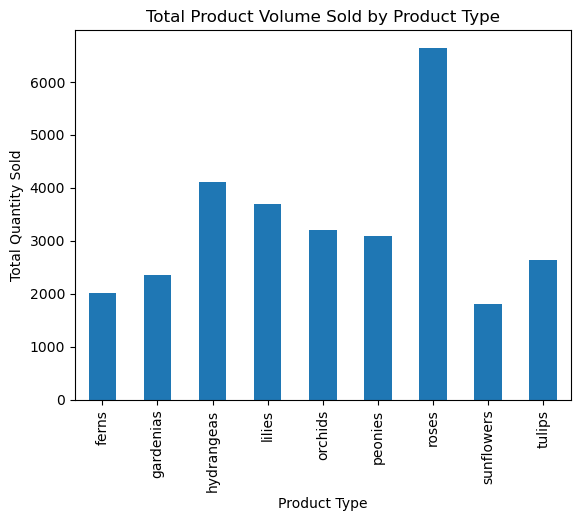

In [27]:
# Total product volume sold by product type
orders_df.groupby("product_category")["quantity_sold"].sum().plot(kind="bar")
plt.title("Total Product Volume Sold by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Total Quantity Sold")
plt.show()


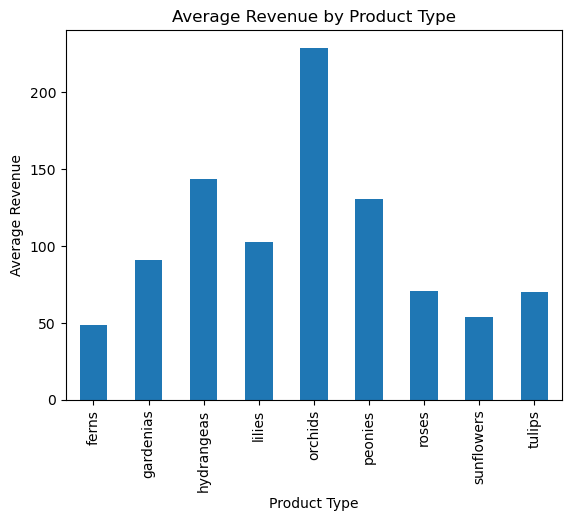

In [28]:
# Average revenue by product type
orders_df.groupby("product_category")["revenue"].mean().plot(kind="bar")
plt.title("Average Revenue by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Revenue")
plt.show()


Text(0, 0.5, 'Average Revenue')

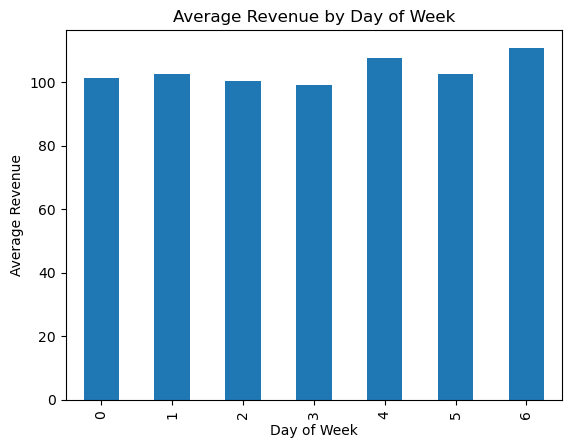

In [29]:
# Average revenue by day of week
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
orders_df["day_of_week"] = orders_df["order_date"].dt.dayofweek
orders_df.groupby("day_of_week")["revenue"].mean().plot(kind="bar")
plt.title("Average Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Revenue")

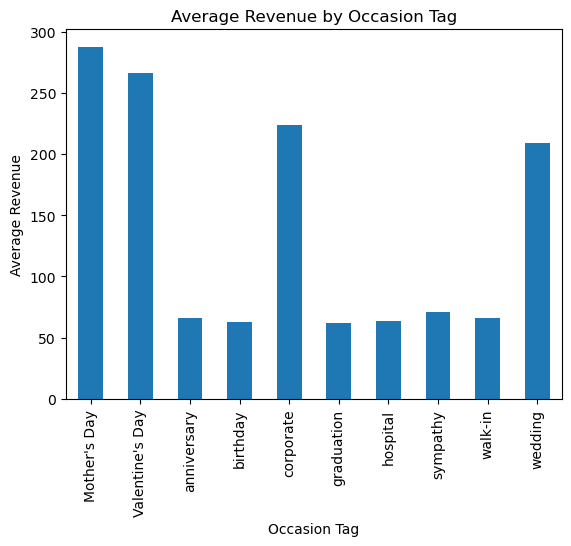

In [30]:
# Average revenue by occasion tag
orders_df.groupby("occasion_tag")["revenue"].mean().plot(kind="bar")
plt.title("Average Revenue by Occasion Tag")
plt.xlabel("Occasion Tag")
plt.ylabel("Average Revenue")
plt.show()

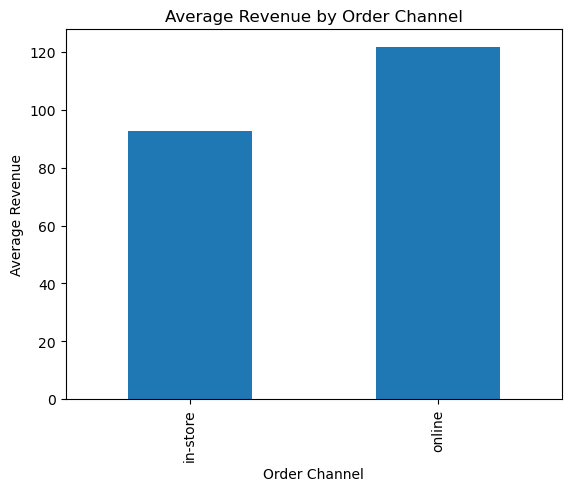

In [31]:
# Average revenue by order channel
orders_df.groupby("order_channel")["revenue"].mean().plot(kind="bar")
plt.title("Average Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Revenue")
plt.show()

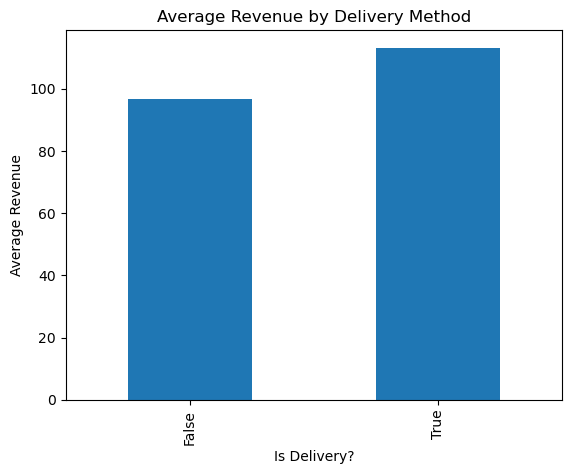

In [32]:
# Average revenue by delivery method
orders_df.groupby("delivery_flag")["revenue"].mean().plot(kind="bar")
plt.title("Average Revenue by Delivery Method")
plt.xlabel("Is Delivery?")
plt.ylabel("Average Revenue")
plt.show()


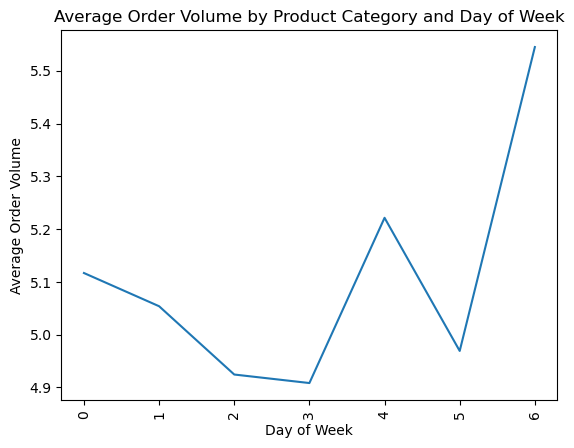

In [33]:
# Average order volume by day of the week (line plot)
orders_df.groupby(["day_of_week"])["quantity_sold"].mean().plot(kind="line")
plt.title("Average Order Volume by Product Category and Day of Week")
plt.xlabel("Day of Week")
plt.xticks(rotation=90)
plt.ylabel("Average Order Volume")
plt.show()




#### Reviews Data

In [34]:
reviews_df.head()

,review_id,platform,review_date,star_rating,review_text,occasion_mentioned
0,REV-001,Google,2023-01-01,5,Love this little shop on Mass Ave. Always stop...,walk-in
1,REV-002,Yelp,2023-01-01,5,Just moved to the area and this place is a hid...,walk-in
2,REV-003,Google,2023-01-03,4,Quick birthday bouquet pickup. In and out in 1...,NaN
3,REV-004,Yelp,2023-01-05,1,Ordered a specific color scheme for a birthday...,NaN
4,REV-005,Yelp,2023-01-08,2,Was browsing and the staff member hovering ove...,walk-in


In [35]:
reviews_df.tail()

,review_id,platform,review_date,star_rating,review_text,occasion_mentioned
305,REV-306,Yelp,2024-12-28,2,Flowers were fine but the delivery was 4 hours...,Valentine's Day
306,REV-307,Google,2024-12-29,5,My husband surprised me with Valentine's flowe...,Valentine's Day
307,REV-308,Google,2024-12-29,4,Grabbed a mixed bouquet for my kitchen table. ...,NaN
308,REV-309,Yelp,2024-12-31,5,Set up a recurring corporate order. They remem...,corporate
309,REV-310,Google,2024-12-31,4,Graduation flowers for my niece. Asked for her...,graduation


In [36]:
reviews_df.describe()

,star_rating
count,310.000000
mean,3.922581
std,1.201593
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


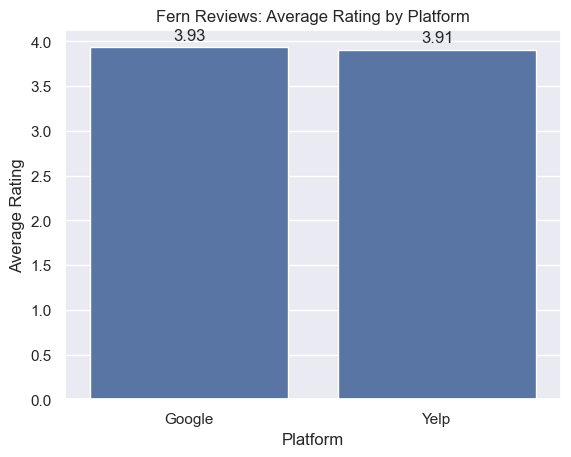

In [37]:
# Average rating by platform
agg = reviews_df.groupby("platform")["star_rating"].mean()

# Seaborn bar plot
sns.set_theme(style="darkgrid")
ax = sns.barplot(x=agg.index, y=agg.values)
plt.title("Fern Reviews: Average Rating by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Rating")

# Add value as text above each bar
for i, v in enumerate(agg.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom")

plt.show()

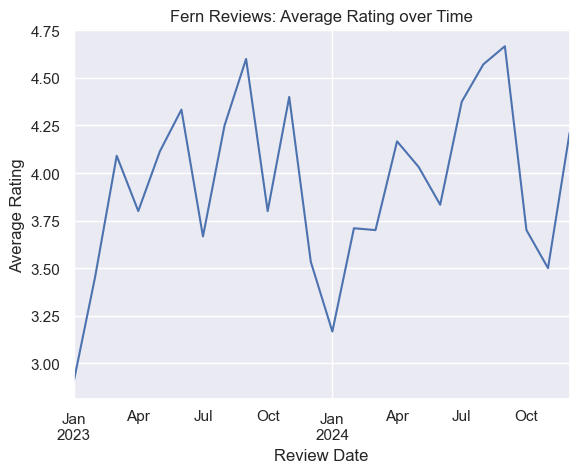

In [38]:
# Average rating over time (group by month)
# Ensure 'review_date' is a datetime type before using .dt accessor
reviews_df["review_date"] = pd.to_datetime(reviews_df["review_date"], errors="coerce")

monthly_avg = (
    reviews_df.groupby(reviews_df["review_date"].dt.to_period("M"))["star_rating"]
    .mean()
    .sort_index()
)

monthly_avg.plot(kind="line")
plt.title("Fern Reviews: Average Rating over Time")
plt.xlabel("Review Date")
plt.ylabel("Average Rating")
plt.show()



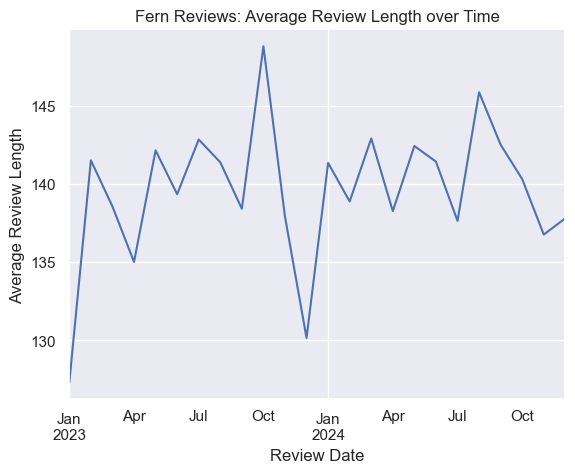

In [39]:
# Average review length over time (group by month)
reviews_df["review_length"] = reviews_df["review_text"].str.len()
monthly_avg_length = (
    reviews_df.groupby(reviews_df["review_date"].dt.to_period("M"))["review_length"]
    .mean()
    .sort_index()
)
monthly_avg_length.plot(kind="line")
plt.title("Fern Reviews: Average Review Length over Time")
plt.xlabel("Review Date")
plt.ylabel("Average Review Length")
plt.show()

# Drop newly created review_length column
reviews_df = reviews_df.drop(columns=["review_length"])


In [40]:
# looking at waste costs!
print(inventory_df.columns)
inventory_df.head()

inventory_df["waste_cost"] = inventory_df["units_wasted"] * inventory_df["unit_cost"]

total_waste = inventory_df["waste_cost"].sum()

print(f"Total Waste Cost: ${total_waste:,.0f}")

Index(['order_week', 'product_category', 'units_ordered', 'units_sold',
       'units_wasted', 'unit_cost', 'unit_price', 'restock_lead_time_days'],
      dtype='object')
Total Waste Cost: $41,394


In [ ]:
# look at waste as a percent of revenue
total_revenue_2yr = orders_df["revenue"].sum()
waste_pct_of_revenue = total_waste / total_revenue_2yr * 100

print(f"Total revenue (2023–2024): ${total_revenue_2yr:,.0f}")
print(f"Waste as % of revenue: {waste_pct_of_revenue:.1f}%")

Total revenue (2023–2024): $598,695
Waste as % of revenue: 6.9%


In [51]:
# checking avg order revenue for special occasions
occasion_summary = (
    orders_df.groupby("occasion_tag")
    .agg(
        avg_order_revenue=("revenue", "mean"),
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity_sold", "sum"),
        num_orders=("revenue", "size")
    )
    .sort_values("avg_order_revenue", ascending=False)
)

print(occasion_summary.round(2))
print("Mother's Day avg order revenue:",
      occasion_summary.loc["Mother's Day", "avg_order_revenue"])

print("Valentine's Day avg order revenue:",
      occasion_summary.loc["Valentine's Day", "avg_order_revenue"])

                 avg_order_revenue  total_revenue  total_quantity  num_orders
occasion_tag                                                                 
Mother's Day                287.38       51728.01            2682         180
Valentine's Day             266.08       50023.23            2724         188
corporate                   223.45      130716.65            5550         585
wedding                     209.14       73617.95            3388         352
sympathy                     71.15       43331.68            2057         609
anniversary                  66.37       26615.69            1352         401
walk-in                      65.98      111969.63            5852        1697
hospital                     63.36       28827.28            1514         455
birthday                     63.22       55127.73            2923         872
graduation                   62.18       26736.71            1494         430
Mother's Day avg order revenue: 287.37783333333334
Valentine's D

In [50]:
# checking waste by product category
waste_by_product = (
    inventory_df.groupby("product_category")
    .agg(
        total_waste_cost=("waste_cost", "sum"),
        total_units_wasted=("units_wasted", "sum"),
        total_units_ordered=("units_ordered", "sum")
    )
)

waste_by_product["waste_rate"] = (
    waste_by_product["total_units_wasted"] / waste_by_product["total_units_ordered"]
)

waste_by_product = waste_by_product.sort_values("total_waste_cost", ascending=False)

print(waste_by_product.round(3))

                  total_waste_cost  total_units_wasted  total_units_ordered  \
product_category                                                              
orchids                    9522.47                 529                 2686   
hydrangeas                 7944.87                 735                 3423   
peonies                    5867.56                 607                 2453   
lilies                     5103.10                 630                 2967   
roses                      4623.59                 929                 5302   
gardenias                  3061.47                 450                 1884   
tulips                     2497.28                 474                 1938   
sunflowers                 1505.06                 381                 1341   
ferns                      1268.68                 315                 1805   

                  waste_rate  
product_category              
orchids                0.197  
hydrangeas             0.215  
peonie

In [ ]:
# -----------------------------
# Baseline waste
# -----------------------------
inventory_df["waste_cost"] = inventory_df["units_wasted"] * inventory_df["unit_cost"]

baseline_waste = inventory_df["waste_cost"].sum()
print(f"Baseline waste: ${baseline_waste:,.0f}")

# -----------------------------
# Simulate realistic forecast-based ordering
# -----------------------------
np.random.seed(42)  # for reproducibility

# simulate imperfect forecast (±30% noise)
inventory_df["forecast"] = inventory_df["units_sold"] * np.random.normal(
    loc=1.0, scale=0.30, size=len(inventory_df)
)

# apply 5% safety buffer
inventory_df["optimal_order"] = np.maximum(
    inventory_df["forecast"] * 1.05,
    inventory_df["units_sold"]
)

# ensure no negative orders
inventory_df["optimal_order"] = inventory_df["optimal_order"].clip(lower=0)

# calculate simulated waste
inventory_df["sim_waste"] = (
    inventory_df["optimal_order"] - inventory_df["units_sold"]
).clip(lower=0)

inventory_df["sim_waste_cost"] = (
    inventory_df["sim_waste"] * inventory_df["unit_cost"]
)

simulated_waste = inventory_df["sim_waste_cost"].sum()
print(f"Simulated waste: ${simulated_waste:,.0f}")

# -----------------------------
# Waste reduction %
# -----------------------------
waste_reduction_pct = (baseline_waste - simulated_waste) / baseline_waste * 100

print(f"Waste reduction: {waste_reduction_pct:.1f}%")

for s in [0.10, 0.20, 0.30]:
    forecast = inventory_df["units_sold"] * np.random.normal(1.0, s, len(inventory_df))
    optimal = np.maximum(forecast * 1.05, inventory_df["units_sold"])
    sim_waste = (optimal - inventory_df["units_sold"]).clip(lower=0) * inventory_df["unit_cost"]
    
    reduction = (baseline_waste - sim_waste.sum()) / baseline_waste * 100
    print(f"Noise {s:.2f}: {reduction:.1f}% reduction")

Baseline waste: $41,394
Simulated waste: $23,006
Waste reduction: 44.4%
Noise 0.10: 71.3% reduction
Noise 0.20: 58.7% reduction
Noise 0.30: 42.0% reduction


### Findings/Analysis

#### Findings / Analysis
**Calendar insights**
- Seasonality is clear: average temperatures peak in **summer (~73.4°F)** and bottom in **winter (~31.8°F)**.
- Holiday weather differs materially: **Mother's Day (~60.5°F)** is much warmer than **Valentine's Day (~30.0°F)** and **Christmas (~35.5°F)**.
- Average precipitation is highest in **winter (~0.092 in)**, while **fall is driest (~0.064 in)**.
- Among holidays, **Mother's Day** has the most precipitation (~0.065 in), while **Christmas** is near zero in this dataset.


**Inventory insights**
- **Roses** drive both throughput and waste: highest average units sold (**~41.3**) and highest average wastage (**~8.8**), indicating high demand but tighter spoilage risk.
- **Hydrangeas** and **lilies/orchids** form the next tier of volume; **sunflowers** and **ferns** are lower-volume.
- Margin structure differs by category: **orchids** have the highest absolute per-unit profit (~$22.0), while **sunflowers/tulips** show strong profit relative to cost.
- Wastage over time is variable (monthly average range roughly **0.0 to 16.5**), suggesting potential operational instability or season/event effects.


**Orders insights**
- Sales mix is concentrated: **roses** lead total quantity sold, while **orchids** lead average order revenue by category.
- Revenue peaks around high-intent occasions: **Mother's Day (~$287)** and **Valentine's Day (~$266)** are far above everyday occasions.
- **Online orders (~$121.7 avg revenue)** outperform **in-store (~$92.6)**, and **delivery orders (~$113.1)** outperform pickup/non-delivery (~$96.8).
- Day-of-week effects are present but moderate: **Sunday** has the highest average revenue and quantity, while midweek is softer.


**Reviews insights**
- Platform ratings are similar and stable overall (**Google ~3.93**, **Yelp ~3.91**).
- Average rating trend improves over time (early period near **2.9**, later period around **4.2**, with peak months reaching ~4.67).
- Average review length trends slightly upward over time, indicating increasingly detailed customer feedback.


**Business implications**
- Forecasting should prioritize **event- and season-aware demand spikes** (especially Mother’s Day/Valentine’s Day and weekends).
- Inventory policy should tighten for **high-velocity/high-waste categories** (especially roses) through better replenishment order frequency.
- Marketing and channel strategy should emphasize **online + delivery** pathways where order values are higher.
- Fern incurred $41,394 in inventory waste costs over 2023–2024, representing approximately 10.8% of total revenue.